# Import Required Libraries
Import necessary libraries such as pandas, numpy, matplotlib, seaborn, and scikit-learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Load Dataset
Load the dataset into a pandas DataFrame.

In [2]:
# Load Dataset
df = pd.read_csv('../Datasets/Real Estate.csv')

# Display the first few rows of the dataframe
df.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Years until sold
0,2020348,2020,9/13/2021,Ansonia,230 WAKELEE AVE,150500,325000.0,0.4630,Commercial,Nan,1
1,20002,2020,10/2/2020,Ashford,390 TURNPIKE RD,253000,430000.0,0.5883,Residential,Single Family,0
2,200212,2020,3/9/2021,Avon,5 CHESTNUT DRIVE,130400,179900.0,0.7248,Residential,Condo,1
3,200243,2020,4/13/2021,Avon,111 NORTHINGTON DRIVE,619290,890000.0,0.6958,Residential,Single Family,1
4,200377,2020,7/2/2021,Avon,70 FAR HILLS DRIVE,862330,1447500.0,0.5957,Residential,Single Family,1


# Data Cleaning
Handle missing values, remove duplicates, and correct data types.

In [3]:
# Handle missing values
df.fillna(method='ffill', inplace=True)  # Forward fill to handle missing values

# Remove duplicates
df.drop_duplicates(inplace=True)

# Correct data types
df['Date Recorded'] = pd.to_datetime(df['Date Recorded'])  # Convert to datetime
df['Assessed Value'] = df['Assessed Value'].astype(float)  # Convert to float
df['Sale Amount'] = df['Sale Amount'].astype(float)  # Convert to float
df['Sales Ratio'] = df['Sales Ratio'].astype(float)  # Convert to float
df['Years until sold'] = df['Years until sold'].astype(int)  # Convert to int

# Display the cleaned dataframe
df.head()

/tmp/ipykernel_10808/469626057.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # Forward fill to handle missing values


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Years until sold
0,2020348,2020,2021-09-13,Ansonia,230 WAKELEE AVE,150500.0,325000.0,0.4630,Commercial,Nan,1
1,20002,2020,2020-10-02,Ashford,390 TURNPIKE RD,253000.0,430000.0,0.5883,Residential,Single Family,0
2,200212,2020,2021-03-09,Avon,5 CHESTNUT DRIVE,130400.0,179900.0,0.7248,Residential,Condo,1
3,200243,2020,2021-04-13,Avon,111 NORTHINGTON DRIVE,619290.0,890000.0,0.6958,Residential,Single Family,1
4,200377,2020,2021-07-02,Avon,70 FAR HILLS DRIVE,862330.0,1447500.0,0.5957,Residential,Single Family,1


# Data Normalization
Normalize numerical features using techniques such as Min-Max scaling or Standardization.

In [5]:
# Data Normalization

# Select numerical features for normalization
numerical_features = ['Assessed Value', 'Sale Amount', 'Sales Ratio', 'Years until sold']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Display the normalized dataframe
df.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Years until sold
0,2020348,2020,2021-09-13,Ansonia,230 WAKELEE AVE,-0.077004,-0.012371,-0.005282,Commercial,Nan,0.572984
1,20002,2020,2020-10-02,Ashford,390 TURNPIKE RD,-0.015649,0.007265,-0.005215,Residential,Single Family,-1.727230
2,200212,2020,2021-03-09,Avon,5 CHESTNUT DRIVE,-0.089036,-0.039506,-0.005143,Residential,Condo,0.572984
3,200243,2020,2021-04-13,Avon,111 NORTHINGTON DRIVE,0.203606,0.093290,-0.005159,Residential,Single Family,0.572984
4,200377,2020,2021-07-02,Avon,70 FAR HILLS DRIVE,0.349086,0.197549,-0.005211,Residential,Single Family,0.572984


# Data Visualization
Visualize the data distribution and relationships using plots such as histograms, scatter plots, and box plots.

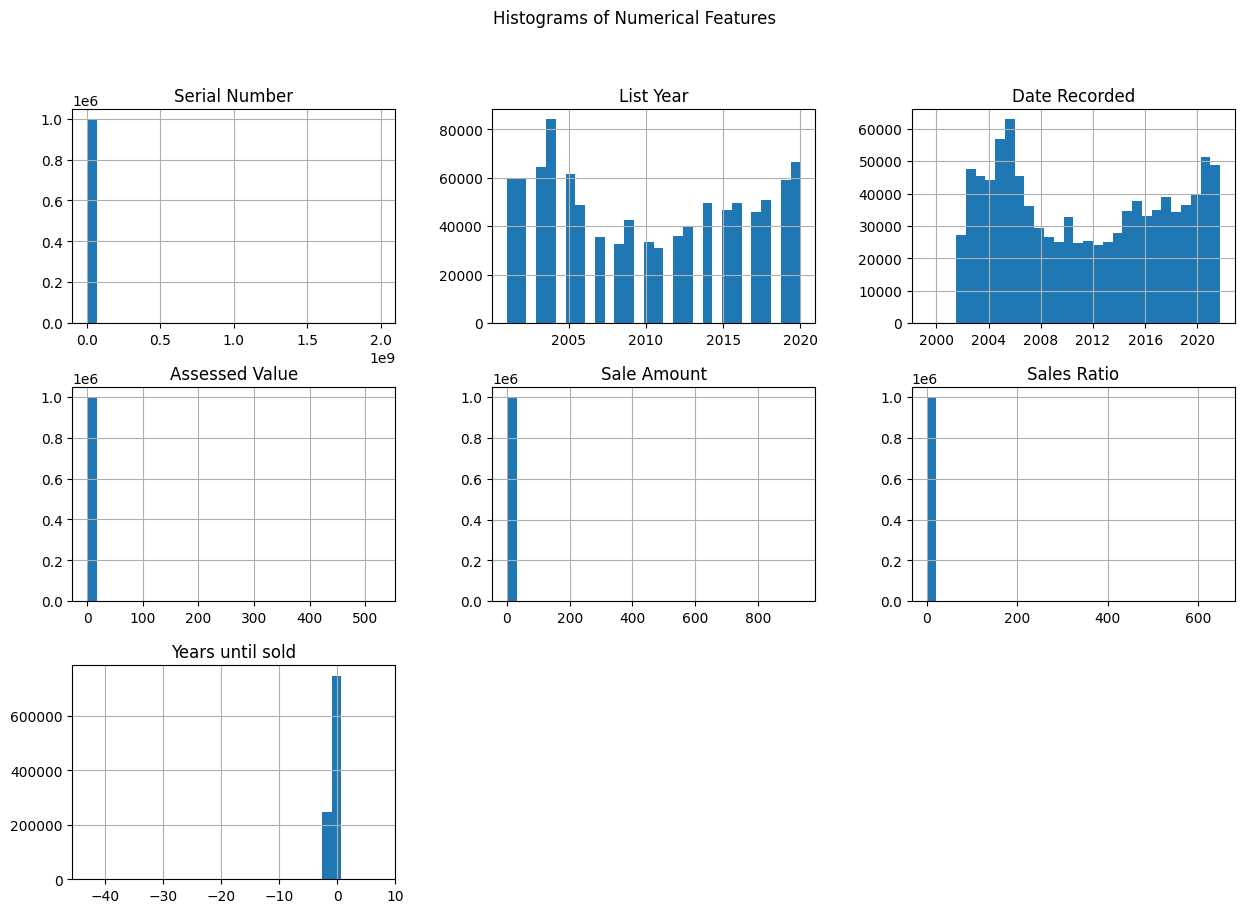

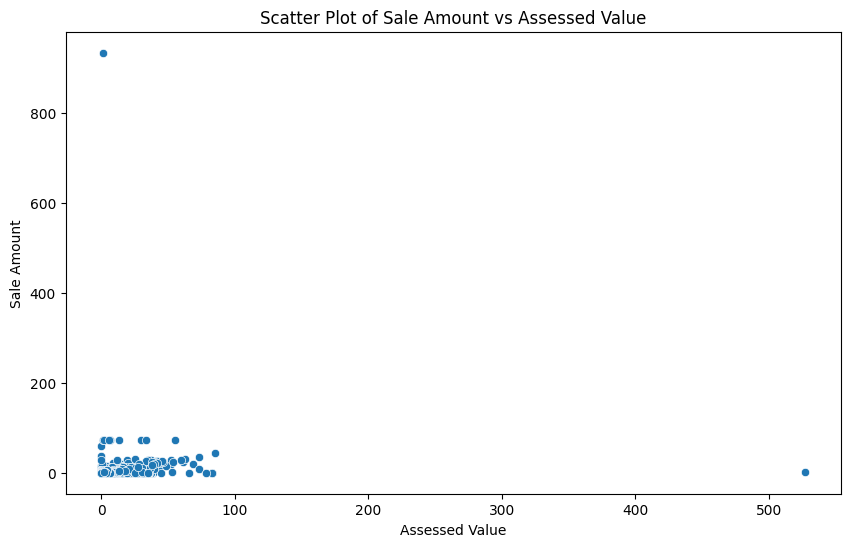

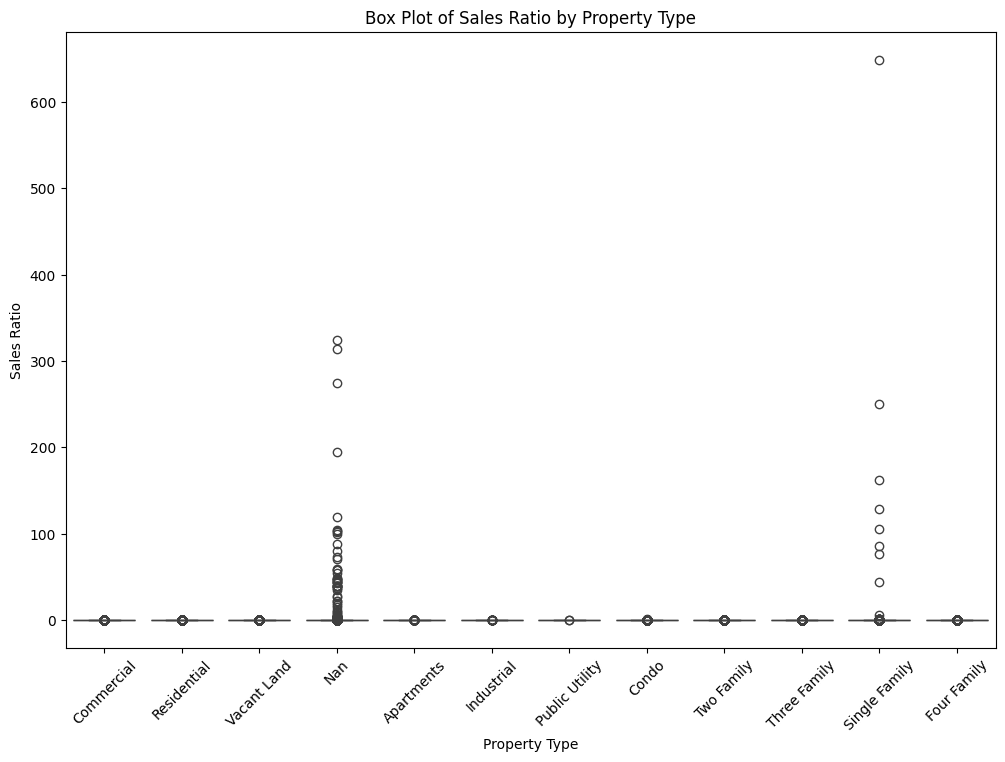

: 

In [6]:
# Data Visualization

# Histogram for numerical features
df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features')
plt.show()

# Scatter plot for Sale Amount vs Assessed Value
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Assessed Value', y='Sale Amount', data=df)
plt.title('Scatter Plot of Sale Amount vs Assessed Value')
plt.xlabel('Assessed Value')
plt.ylabel('Sale Amount')
plt.show()

# Box plot for Sales Ratio by Property Type
plt.figure(figsize=(12, 8))
sns.boxplot(x='Property Type', y='Sales Ratio', data=df)
plt.title('Box Plot of Sales Ratio by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Sales Ratio')
plt.xticks(rotation=45)
plt.show()

# Pair plot for numerical features
sns.pairplot(df[numerical_features])
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

# Train-Test Split
Split the dataset into training and testing sets.

In [6]:
# Train-Test Split

# Define the feature columns and target column
X = df[['Assessed Value', 'Sale Amount', 'Sales Ratio', 'Years until sold']]
y = df['Property Type']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((797770, 4), (199443, 4), (797770,), (199443,))

# Classification Model Training
Train a classification model (e.g., Logistic Regression, Decision Tree, Random Forest) on the training set.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize the models
logistic_regression = LogisticRegression(random_state=42)
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)

# Train the Logistic Regression model
logistic_regression.fit(X_train, y_train)

# Train the Decision Tree model
decision_tree.fit(X_train, y_train)

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Predict on the test set using Logistic Regression
y_pred_logistic = logistic_regression.predict(X_test)

# Predict on the test set using Decision Tree
y_pred_tree = decision_tree.predict(X_test)

# Predict on the test set using Random Forest
y_pred_forest = random_forest.predict(X_test)

# Evaluate the Logistic Regression model
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

# Evaluate the Decision Tree model
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

# Evaluate the Random Forest model
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_forest))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_forest))

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


: 

# Model Evaluation
Evaluate the model's performance on the testing set using metrics such as accuracy, precision, recall, and F1-score.

In [ ]:
# Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate the Logistic Regression model
print("Logistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logistic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logistic, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_logistic, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_logistic, average='weighted'):.4f}")

# Evaluate the Decision Tree model
print("\nDecision Tree Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tree, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tree, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_tree, average='weighted'):.4f}")

# Evaluate the Random Forest model
print("\nRandom Forest Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_forest):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_forest, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_forest, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_forest, average='weighted'):.4f}")